Inputs shape: (21, 3)
Outputs shape: (21,)
First 20 rows of raw data:
    compound-1  compound-2  compound-3  trans-side-effect  source
18    0.448900    0.470829    0.414315          -0.020404  week-4
16    0.303031    0.242424    0.474748          -0.030680  week-2
3     0.492581    0.611593    0.340176          -0.034835    file
13    0.600097    0.725136    0.066089          -0.036378    file
10    0.220549    0.297825    0.343555          -0.046947    file
4     0.134622    0.219917    0.458206          -0.048008    file
17    0.263346    0.138532    0.363743          -0.048179  week-3
14    0.965995    0.861120    0.566829          -0.056758    file
1     0.242114    0.644074    0.272433          -0.087963    file
9     0.170477    0.697032    0.149169          -0.094190    file
11    0.666014    0.671985    0.246295          -0.105965    file
5     0.345523    0.941360    0.269363          -0.110621    file
15    0.464647    0.666667    0.171718          -0.111186  week-1
2     

/Users/ajay.amrite/Documents/AI Course/Capstone/Black-Box functions/models/SurrogateNN.py:117: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226260/work/aten/src/ATen/native/ReduceOps.cpp:1760.)
  "std": param.data.std().item()


Epoch 1/500, Train Loss: 1.180484, Val Loss: 0.598650
Epoch 50/500, Train Loss: 0.258872, Val Loss: 1.011814
Early stopping at epoch 59, best val_loss=0.582392


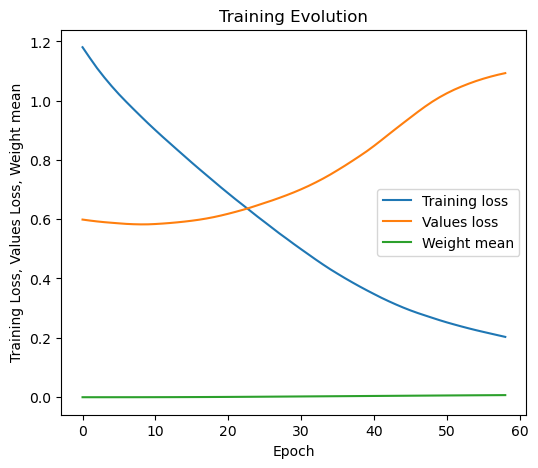

Using 3 dimensions, grid size per axis: 200, downsample: True, stride: 4
Points before downsampling: 8000000
Points after downsampling: 125000
Final grid shape: (125000, 3)
Filtered 2019 candidates using filter_strategy='boundary'
Predictions range (scaled): -0.2167 to 0.1463
Inverse-transforming predictions to raw units
Predictions range (raw): -0.1159 to -0.0880
Total number of points to evaluate: 6
{'method': 'PI', 'xi': 0.0, 'kappa': None, 'x': array([0.4769726 , 0.21730851, 0.31416776]), 'score': 6.287423961159923e-06, 'dim': 3, 'predicted_y': -0.098521344}
{'method': 'PI', 'xi': 0.01, 'kappa': None, 'x': array([0.4769726 , 0.21730851, 0.31416776]), 'score': 5.161623831947811e-06, 'dim': 3, 'predicted_y': -0.098521344}
{'method': 'EI', 'xi': 0.0, 'kappa': None, 'x': array([0.4769726 , 0.21730851, 0.31416776]), 'score': 3.0707582125397717e-07, 'dim': 3, 'predicted_y': -0.098521344}
{'method': 'EI', 'xi': 0.01, 'kappa': None, 'x': array([0.4769726 , 0.21730851, 0.31416776]), 'score'

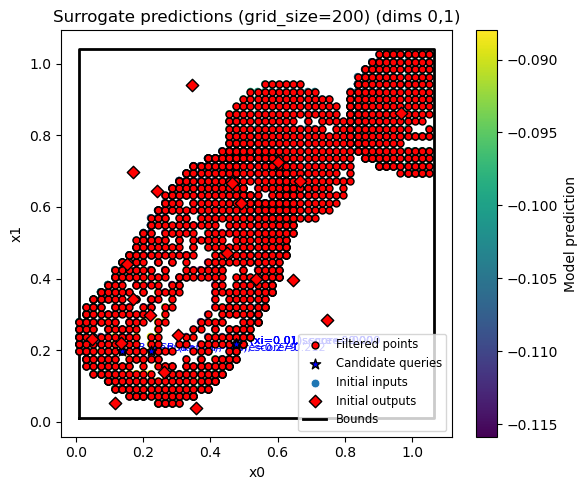

<Figure size 600x500 with 0 Axes>

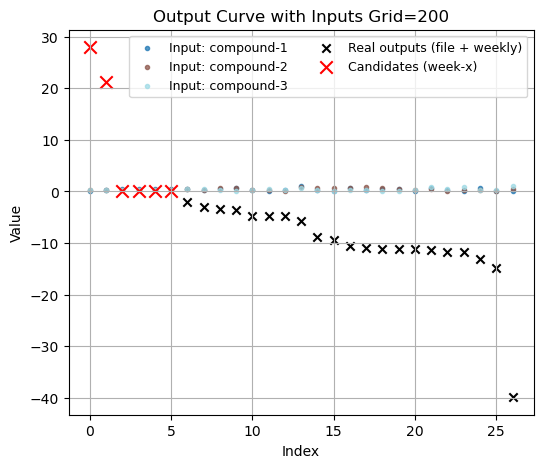

Saved dataframe to: results/run_2025-12-13 15-50-21/df_grid_200_stride4_gp_max_raw_lr0.001_ep500.csv
Best candidate: {'method': 'UCB', 'xi': None, 'kappa': 1.0, 'x': array([0.13735616, 0.19657766, 0.29244149]), 'score': 0.27943834389459643, 'dim': 3, 'predicted_y': -0.0885753}
    compound-1  compound-2  compound-3  trans-side-effect  source  trans-side-effect-scaled
0     0.137356    0.196578    0.292441       2.794383e-01  week-x                 10.000000
1     0.222260    0.196578    0.248989       2.117584e-01  week-x                  7.578002
2     0.476973    0.217309    0.314168       6.287424e-06  week-x                  0.000225
3     0.476973    0.217309    0.314168       5.161624e-06  week-x                  0.000185
4     0.476973    0.217309    0.314168       3.070758e-07  week-x                  0.000011
5     0.476973    0.217309    0.314168       2.500072e-07  week-x                  0.000009
6     0.448900    0.470829    0.414315      -2.040441e-02  week-4             

In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (12, 8)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh)

print("Pipeline finished. Results keys:", list(results.keys()))